In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

np.random.seed(42)

## Генерация выборки

In [2]:
# Параметры распределения
n = 25
scale = 1.0  # scale = 1/lambda. p(x) = e^(-x), lambda=1.

# Генерируем выборку
sample = np.random.exponential(scale=scale, size=n)

sample[:5]

array([0.46926809, 3.01012143, 1.31674569, 0.91294255, 0.16962487])

## Подсчет статистик

In [3]:
# Медиана
median_val = np.median(sample)

In [4]:
median_val

0.4692680899768591

In [5]:
# Размах 
range_val = np.max(sample) - np.min(sample)

In [6]:
range_val

3.4827581671591736

In [7]:
# Оценка коэффициента асимметрии
# Среднее
mean_val = np.mean(sample)

# Центрирование выборки
centered_sample = sample - mean_val

m2 = np.mean(centered_sample ** 2)
m3 = np.mean(centered_sample ** 3)

coef_asymmetry = m3 / (m2 ** 1.5)

In [8]:
coef_asymmetry

1.6998221113390404

In [9]:
from collections import Counter

# Мода
# Формируем частотный словарь по выборке

counts = Counter(sample)

In [10]:
counts

Counter({0.4692680899768591: 1,
         3.010121430917521: 1,
         1.3167456935454493: 1,
         0.9129425537759532: 1,
         0.16962487046234628: 1,
         0.16959629191460518: 1,
         0.059838768608680676: 1,
         2.0112308644799395: 1,
         0.9190821536272645: 1,
         1.2312500617045903: 1,
         0.020799307999138622: 1,
         3.503557475158312: 1,
         1.786429543354675: 1,
         0.238687625248947: 1,
         0.20067898874966336: 1,
         0.20261142283225705: 1,
         0.3627537294604771: 1,
         0.7439278308608545: 1,
         0.5655370667803367: 1,
         0.3442229925539415: 1,
         0.9463708738997987: 1,
         0.15023452872733867: 1,
         0.34551551200240227: 1,
         0.45627721822084705: 1,
         0.608934687859775: 1})

In [11]:
# Берем из словаря самый часто встречающийся элемент (моду)

value = [x for x in counts if counts[x] == max(counts.values())][0]

value

0.4692680899768591

## Построение графиков

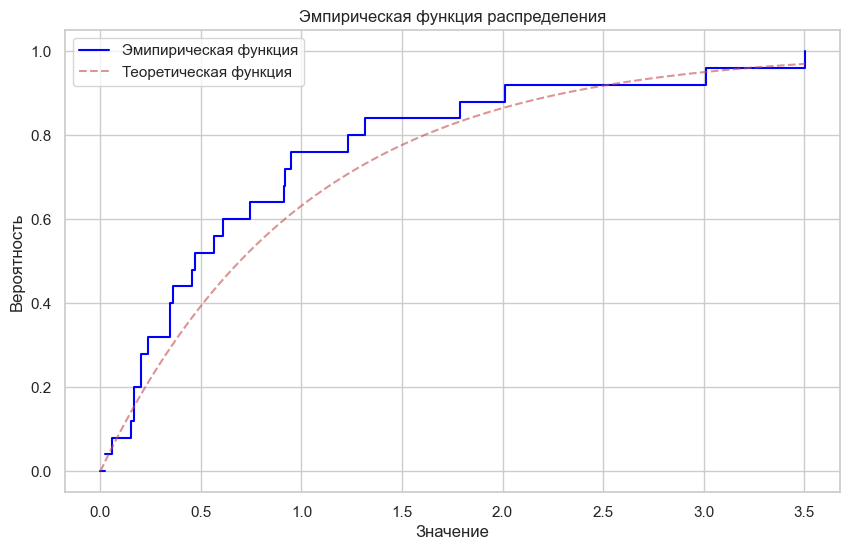

In [12]:
# Сортируем выборку
x_sorted = np.sort(sample)

# y_values показывает долю наблюдений, меньших или равных текущему x
y_values = np.arange(1, len(sample) + 1) / len(sample)

# Строим ступенчатый график
plt.step(x_sorted, y_values, where='post', label='Эмипирическая функция', color='blue')

if x_sorted[0] > 0:
    plt.step([0, x_sorted[0]], [0, 0], where='post', color='blue')


x_theor = np.linspace(0, np.max(sample), 100)
y_cdf = stats.expon.cdf(x_theor, scale=scale) 

plt.plot(x_theor, y_cdf, 'r--', label='Теоретическая функция', alpha=0.6)

plt.title("Эмпирическая функция распределения")
plt.xlabel("Значение")
plt.ylabel("Вероятность")
plt.legend()

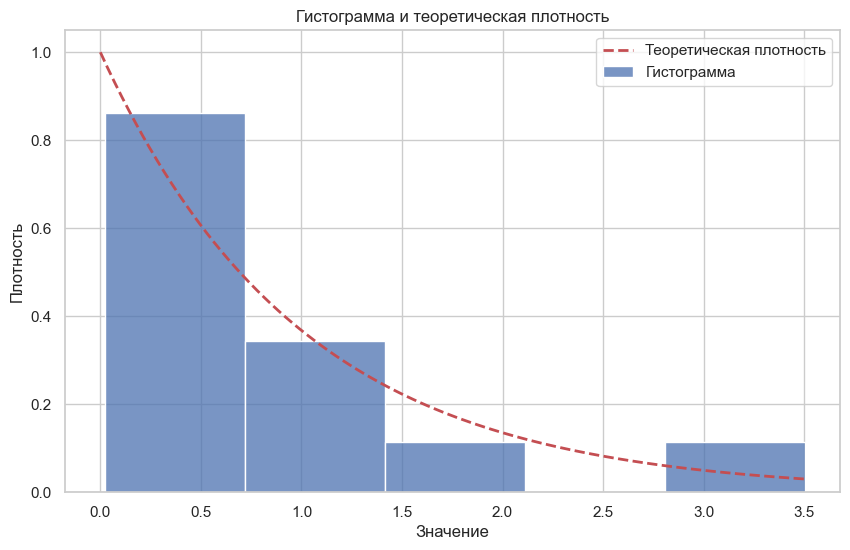

In [13]:
# Гистограмма
sns.histplot(sample, stat='density', bins=int(1 + np.log2(n)), label='Гистограмма')

# Теоретическая плотность
x_theor = np.linspace(0, np.max(sample), 100)
y_pdf = stats.expon.pdf(x_theor, scale=scale)

plt.plot(x_theor, y_pdf, 'r--', label='Теоретическая плотность', linewidth=2)

plt.title("Гистограмма и теоретическая плотность")
plt.xlabel("Значение")
plt.ylabel("Плотность")
plt.legend()

Text(0.5, 0, 'Значение')

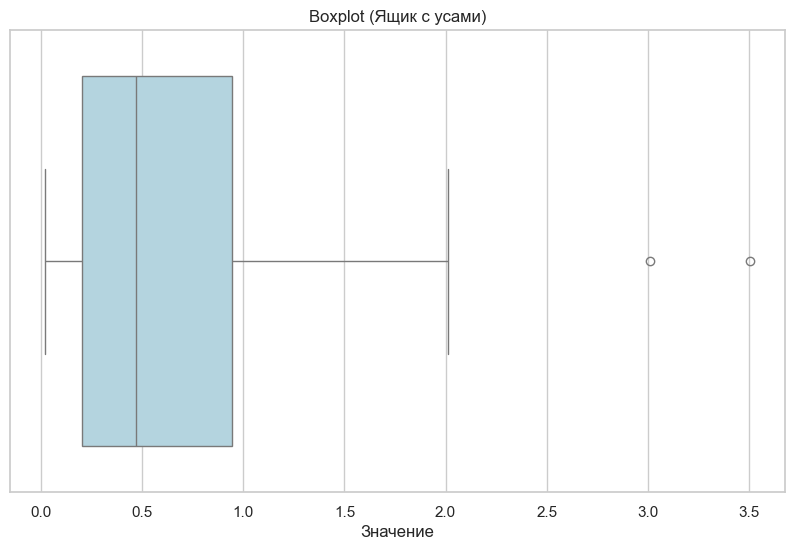

In [14]:
plt.figure(figsize=(10, 6))

# Boxplot
sns.boxplot(x=sample, color='lightblue')

plt.title("Boxplot (Ящик с усами)")
plt.xlabel("Значение")

## ЦПТ vs Бутстрап

Согласно **Простейшей ЦПТ**, выборочное среднее $\bar{X}$ имеет асимптотически нормальное распределение с параметрами $N(\mu, \frac{\sigma^2}{n})$.

Для экспоненциального распределения с параметром $\lambda = 1$:
* Математическое ожидание: $\mu = \frac{1}{\lambda} = 1$
* Дисперсия: $\sigma^2 = \frac{1}{\lambda^2} = 1$

При объеме выборки $n = 25$ параметры нормального закона для среднего будут:
$$\bar{X} \sim-> N\left(1, \frac{1}{25}\right) \$$

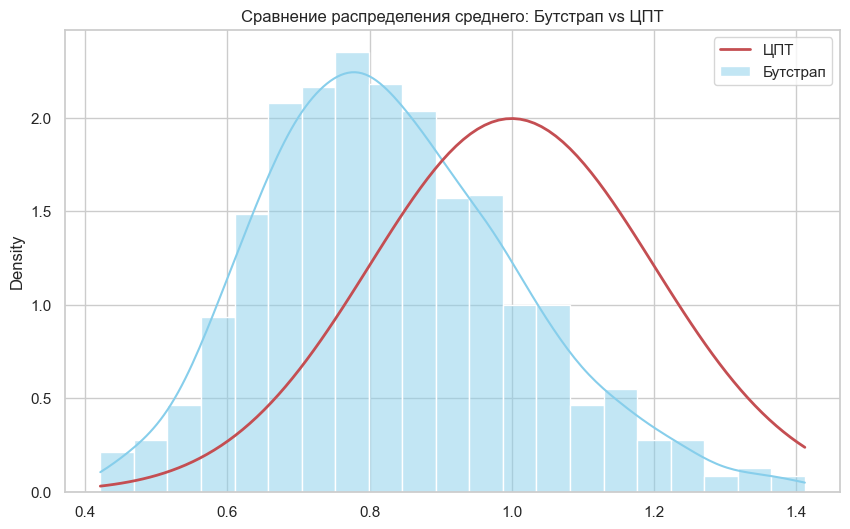

In [15]:
# Бутстрап для среднего
n_boot = 1000
bootstrap_means = []

for _ in range(n_boot):
    boot_sample = np.random.choice(sample, size=n, replace=True)  # Генерация выборок длины n с возвращением
    bootstrap_means.append(np.mean(boot_sample))  # Сохраняем подсчитанное среднее

# Визуализация
plt.figure(figsize=(10, 6))

# Бутстраповская оценка
sns.histplot(bootstrap_means, kde=True, stat="density", label="Бутстрап", color="skyblue", alpha=0.5)

# Оценка по ЦПТ (Нормальное распределение)
mu_clt = 1  # M[x] = 1
sigma_clt = np.sqrt(1 / n) 

x_clt = np.linspace(min(bootstrap_means), max(bootstrap_means), 100)
pdf_clt = stats.norm.pdf(x_clt, loc=mu_clt, scale=sigma_clt)

plt.plot(x_clt, pdf_clt, 'r-', linewidth=2, label="ЦПТ")

plt.title("Сравнение распределения среднего: Бутстрап vs ЦПТ")
plt.legend()

## Бутстраповская оценка плотности коэффициента ассиметрии

Вероятность того, что коэффициент асимметрии < 1: 0.0880


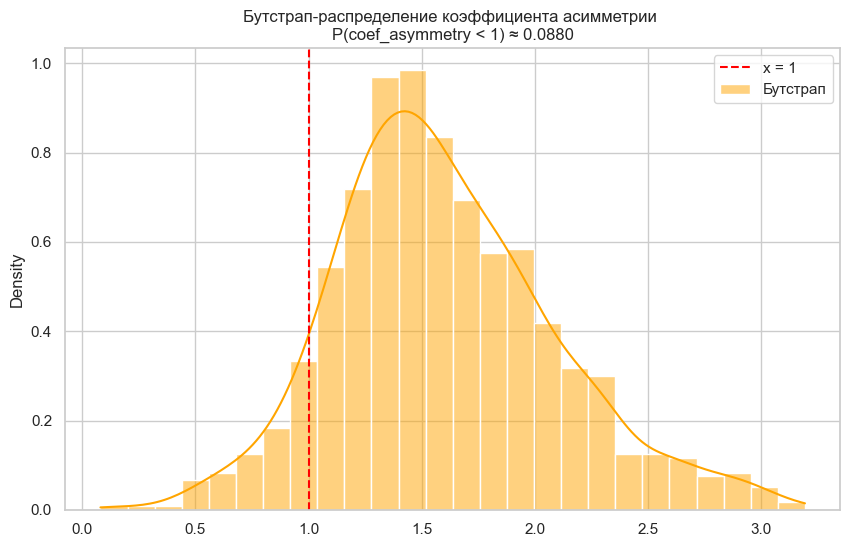

In [16]:
# Определим функцию для расчета оценки коэффициента асимметрии
def calculate_coef_asymmetry(data):
    mean_d = np.mean(data)
    centered_d = data - mean_d
    m2_d = np.mean(centered_d ** 2)
    m3_d = np.mean(centered_d ** 3)
    
    # Защита от деления на ноль (если вдруг выборка из одинаковых чисел)
    if m2_d == 0:
        return 0
        
    return m3_d / (m2_d ** 1.5)

# Бутстрап
n_boot = 1000
bootstrap_coefs_asymmetry = []

for _ in range(n_boot):
    # Генерация подвыборки с возвращением
    boot_sample = np.random.choice(sample, size=n, replace=True)
    
    # Расчет асимметрии
    coef_asymmetry_boot = calculate_coef_asymmetry(boot_sample)
    bootstrap_coefs_asymmetry.append(coef_asymmetry_boot)

bootstrap_coefs_asymmetry = np.array(bootstrap_coefs_asymmetry)

# Оценка вероятности P(coef_asymmetry < 1)
prob_coef_asymmetry_less_1 = np.mean(bootstrap_coefs_asymmetry < 1)

plt.figure(figsize=(10, 6))
sns.histplot(bootstrap_coefs_asymmetry, kde=True, stat="density", color="orange", label="Бутстрап")
plt.axvline(1, color='red', linestyle='--', label='x = 1')
plt.title(f"Бутстрап-распределение коэффициента асимметрии \nP(coef_asymmetry < 1) ≈ {prob_coef_asymmetry_less_1:.4f}")
plt.legend()

print(f"Вероятность того, что коэффициент асимметрии < 1: {prob_coef_asymmetry_less_1:.4f}")

## Сравнение плотности распределения медианы выборки с бутстраповской оценкой этой плотности

In [17]:
bootstrap_medians = []

for _ in range(n_boot):
  bootstrap_medians.append(np.median(np.random.choice(sample,
                                                      size=len(sample),
                                                      replace=True)))

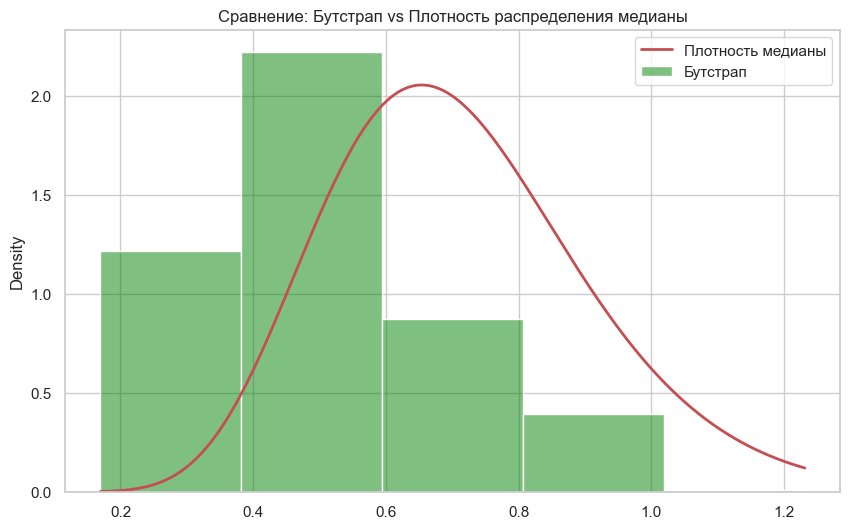

In [18]:
import scipy.special as sp

# Определяем k (индекс медианы)
k = n // 2 + 1

# Определяем теоретическую плотность (p) и функцию распределения (F)
# для экспоненциального распределения (lambda=1)
def p_theory(x):
    return np.exp(-x)  # pdf

def F_theory(x):
    return 1 - np.exp(-x) # cdf

# Функция плотности медианы
def exact_median_pdf(x):
    #  N * C(N-1, k-1) * f(x) * F(x)^(k-1) * (1-F(x))^(N-k)
    comb_val = sp.comb(n - 1, k - 1)
    return n * p_theory(x) * comb_val * (F_theory(x) ** (k - 1)) * ((1 - F_theory(x)) ** (n - k))

plt.figure(figsize=(10, 6))

sns.histplot(bootstrap_medians, kde=False, stat="density", color="green", label="Бутстрап", alpha=0.5, bins=int(1 + np.log2(n)))

x_vals = np.linspace(min(bootstrap_medians), max(bootstrap_medians), 200)
y_vals = [exact_median_pdf(xi) for xi in x_vals]

plt.plot(x_vals, y_vals, 'r-', linewidth=2, label="Плотность медианы")

plt.title("Сравнение: Бутстрап vs Плотность распределения медианы")
plt.legend()